# AG-HYPOPT · Trial 09

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Eight trials recorded: trial_01 0.1907, trial_02 0.2075, trial_03 0.2472, trial_04 0.1987, trial_05 0.1863 (best), trial_06 0.2203, trial_07 0.1940, trial_08 0.1948. Recap: mu_fit sits at ~half of mu_true for every config (objective floor, insensitive to the knobs); the objective spread comes from the gamma term, dominated by the low-transmission (Trans05/Trans20) estimate. gamma_anneal is the clearest lever: very low anneal (trial_03, 0.064) was worst; a broad band of moderate-to-high anneal (0.38-0.74) ranges from best to middling, so no single knob yet fixes the low-T gamma instability. TPE (8/5) is ranking candidates; several top picks are now pushing parameters to the space boundaries. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_09'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (8/5 trials)
ID |     ei | params
 1 | 3.4239 | {"gamma_anneal": 0.4100279848627326, "lr_gamma": 0.8844952605812364, "lr_mu": 6.546371917884403, "sigma_ref": 25.0}
 2 | 2.3903 | {"gamma_anneal": 0.32793600009713153, "lr_gamma": 0.9283475402717776, "lr_mu": 25.765535924281426, "sigma_ref": 25.0}
 3 | 1.5961 | {"gamma_anneal": 0.5290002784420903, "lr_gamma": 0.792598786300599, "lr_mu": 24.56477288320329, "sigma_ref": 25.0}
 4 | 2.9580 | {"gamma_anneal": 0.34237865177438787, "lr_gamma": 0.9105783164687224, "lr_mu": 5.0, "sigma_ref": 5.0}
 5 | 0.4231 | {"gamma_anneal": 0.5371824759348653, "lr_gamma": 0.24980279793333074, "lr_mu": 29.069539622929067, "sigma_ref": 9.521966547263428}
 6 | 2.2621 | {"gamma_anneal": 0.7217510562199954, "lr_gamma": 0.9178024787840744, "lr_mu": 7.5959993890622695, "sigma_ref": 8.786640388564619}
 7 | 1.5974 | {"gamma_anneal": 0.4824896316017035, "lr_gamma": 0.33551425044507144, "lr_mu": 5.0, "sigma_ref": 21.69461356311947}
 8 | 1.8649 | {"gamma_an

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (8/5) ranks by expected improvement. The highest-EI candidate is candidate 1 (EI 3.42): gamma_anneal 0.410, lr_gamma 0.884, lr_mu 6.55, sigma_ref 25.0. Its anneal (0.41) is moderate, not in the harmful near-zero regime (the worst trial used 0.064), and sits in the broad band of anneal values that have scored well (trial_01 at 0.384 scored 0.1907; trial_07 at 0.599 scored 0.1940); sigma_ref near the 25.0 boundary also has precedent (trial_01 at 23.97). Several other candidates push multiple parameters onto boundaries simultaneously (candidate 4: lr_mu and sigma_ref both at hard bounds; candidates 2, 3, 8: sigma_ref 25.0), which is a less clean extrapolation. So the top-EI pick is also a reasonable, well-precedented region. I choose candidate 1.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # highest-EI TPE pick


chosen: {'gamma_anneal': 0.4100279848627326, 'lr_gamma': 0.8844952605812364, 'lr_mu': 6.546371917884403, 'sigma_ref': 25.0}
Running  1nW Trans05 ... 

μ 9.39 -> 4.70 | γ 8.5 -> 12.77 | NLL 1.38


Running  1nW Trans20 ... 

μ 17.32 -> 8.67 | γ 8.5 -> 4.11 | NLL 2.88


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 51.17 | γ 14.1 -> 13.61 | NLL 3.08


Running 3nW Trans100 ... 

μ 175.71 -> 87.08 | γ 14.1 -> 13.94 | NLL 3.43



Total: 2.4 min


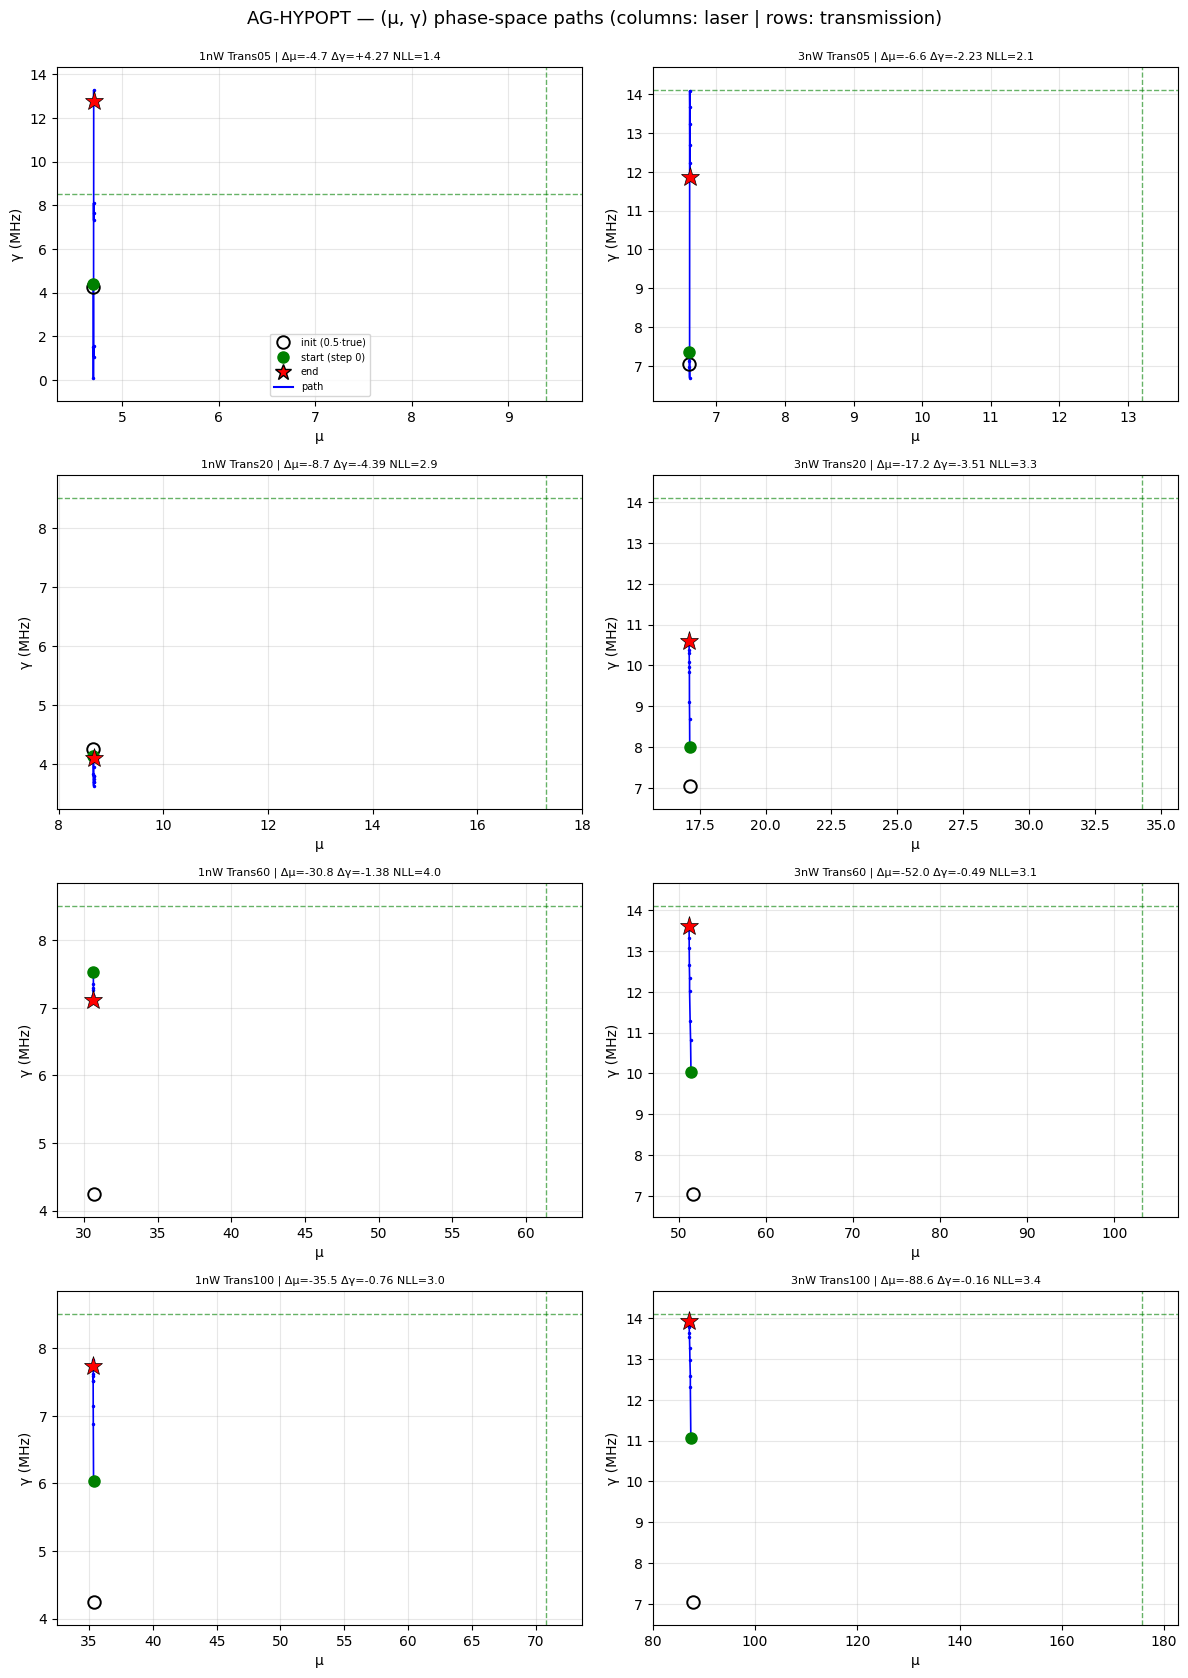

trial finished in 2.4 min
objective = 0.1657 ± 0.0293
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.70   -49.9 |     8.50   12.77   +50.2
1nW Trans20    17.32    8.67   -50.0 |     8.50    4.11   -51.6
1nW Trans60    61.37   30.62   -50.1 |     8.50    7.12   -16.3
1nW Trans100   70.82   35.34   -50.1 |     8.50    7.74    -8.9
3nW Trans05    13.20    6.61   -49.9 |    14.10   11.87   -15.8
3nW Trans20    34.28   17.10   -50.1 |    14.10   10.59   -24.9
3nW Trans60   103.20   51.17   -50.4 |    14.10   13.61    -3.5
3nW Trans100  175.71   87.08   -50.4 |    14.10   13.94    -1.1

μ: RMSE 40.623 (rel 50.1%, bias -30.500) | γ: RMSE 2.682 (rel 28.3%, bias -1.082)


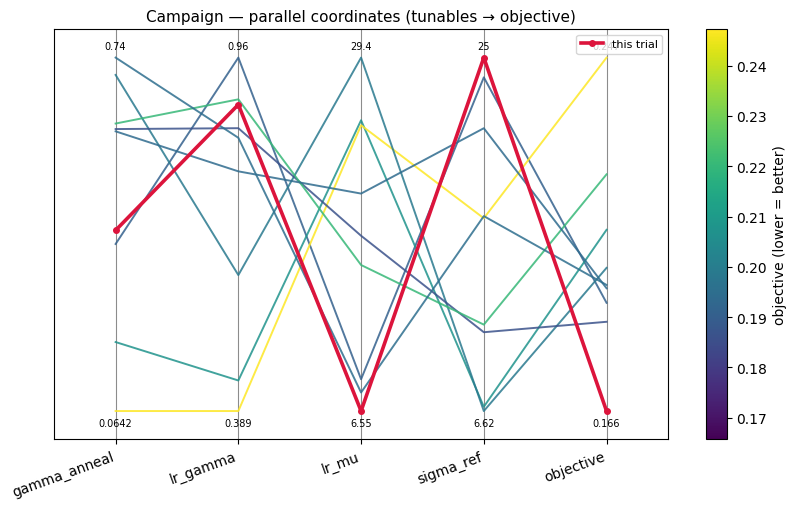

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 09, fourth TPE-driven trial; highest-EI pick: sigma_ref 25.0, lr_mu 6.55, lr_gamma 0.884, gamma_anneal 0.410. Result: objective 0.1657 +/- 0.0293 -- the NEW campaign best, beating trial_05 (0.1863) by a clear margin; runtime 2.4 min. mu_fit is, as always, near half of mu_true and now extremely uniform (Delta-mu% -49.9 to -50.4 across all 8 experiments), giving mu RMSE 40.62 (relative 50.1%, bias -30.5) -- the best mu RMSE yet. gamma_fit is the best of the campaign: RMSE 2.68 (relative 28.3%, bias -1.1). High transmission is near-truth (3 nW Trans60/100: -3.5/-1.1%; 1 nW Trans100: -8.9%), and notably the Trans05 gate improved: 3 nW Trans05 -15.8% (usually -55..-85%) though 1 nW Trans05 overshoots to +50.2% and 1 nW Trans20 is still -51.6%. So this config substantially reduced the gamma term while leaving mu at the same half-truth floor.

**Summary:** Trial 09 (sigma_ref 25.0, lr_mu 6.55, lr_gamma 0.884, gamma_anneal 0.410) -> objective 0.1657 +/- 0.0293, new campaign best; mu at a perfectly uniform half-truth, gamma RMSE best yet (28.3% rel) with Trans05 partly rescued.
**Key insight:** A config with sigma_ref at the 25.0 boundary and low lr_mu gave the campaign's best objective by cutting the gamma term sharply (3 nW Trans05 -15.8%) while the mu attractor stayed pinned at exactly half-truth.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 09 (sigma_ref 25.0, lr_mu 6.55, lr_gamma 0.884, gamma_anneal 0.410): objective 0.1657 +/- 0.0293, new campaign best; mu at a uniform half-truth, gamma RMSE best yet (28.3% rel)'
KEY_INSIGHT = 'A sigma_ref=25.0 / low-lr_mu config cut the gamma term sharply (3 nW Trans05 -15.8%) for the best objective so far, while the mu attractor remained pinned at exactly half-truth.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_09 | current best: trial_09


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_10.ipynb. Open it and follow its cells from the top.
